# 01 – Multiple Lineare Regression

Erstes "echtes" ML-Modell nach den naiven Baselines.  
Zwei Varianten werden verglichen:

| Modell      | Features                                                                     |
|-------------|------------------------------------------------------------------------------|
| **Model A** | Strahlung + Wetter (4 Features, **ohne** Zeitfeatures)                       |
| **Model B** | + `hour_cos_shifted`, `month_cos_shifted` (6 Features, **mit** Zeitfeatures) |

**Forschungshypothesen:**
- **H2:** Zeitliche Merkmale (Uhrzeit, Jahreszeit) verbessern die Prognose signifikant (MAE(mit Zeit) < MAE(ohne))

## 0 · Setup

In [14]:
import sys
sys.path.insert(0, '../..')

from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from src.data.preprocessing import load_processed_data
from src.data.splitting import time_series_split, split_summary
from src.features.feature_sets import FEATURE_SETS
from src.models.baseline import train_linear_baseline, predict
from src.models.naive import fit_climatological_mean_by_season, predict_climatological_mean_by_season
from src.models.pipeline import run_pipeline, evaluate_on_test
from src.evaluation.metrics import evaluate, persistence_forecast

P_NOM = 13_500.0
TARGET = "Solarproduktion"
RESULTS_DIR = Path("../../results/01_linear_regression")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
RUN_TEST = False  # flip to True once, deliberately, when finalizing results

FEATURES_A = FEATURE_SETS["BASE"].features
FEATURES_B = FEATURE_SETS["BASE_WITH_TIME"].features

plt.rcParams.update({"figure.dpi": 120, "axes.grid": True, "grid.alpha": 0.3})

## 1 · Daten laden & Split

## 2 · Feature-Übersicht

Features werden aus `data/processed/features.csv` geladen (vorberechnet in `04_feature_engineering.ipynb`).

| Feature                  | Quelle      | Warum?                                                                                                                                                                                                                                  |
|--------------------------|-------------|-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| `ghi_cloudy_sky`         | Irradiance  | Wichtigster PV-Treiber: Globalstrahlung unter realen Bedingungen                                                                                                                                                                        |
| `clear_sky_index`        | Irradiance  | GHI / GHI_clear – normiert Strahlung auf den theoretischen Klarhimmelwert; entkoppelt Bewölkungseffekt von Tageszeit und Jahreszeit. Wertebereich 0–1.                                                                                  |
| `hour_cos_shifted`       | Timestamp   | Phasenverschobener Kosinus der Tagesstunde mit Peak bei 12 Uhr (h★=12). Kodiert Tageszeit symmetrisch zur Mittagsproduktion.                                                                                                            |
| `month_cos_shifted`      | Timestamp   | Phasenverschobener Kosinus des Monats mit Peak im Juni (m★=6). Erfasst Saisonalität korrekt.                                                                                                                                            |
| `temperature_2m`         | Wetter      | Hohe Temperatur senkt den Wirkungsgrad (meist −0,3 bis −0,45%/K)                                                                                                                                                                        |
| `cloud_cover_low`        | Wetter      | Niedrige Wolken blockieren Direktstrahlung am stärksten                                                                                                                                                                                 |

| Modell | Features |
|---|---|
| **Model A** | Strahlung + Wetter (4 Features, **ohne** Zeitfeatures) |
| **Model B** | + `hour_cos_shifted`, `month_cos_shifted` (6 Features, **mit** Zeitfeatures) |

In [10]:
df = load_processed_data()
train, val, test = time_series_split(df)

train = train.dropna(subset=FEATURES_B + [TARGET])
val   = val.dropna(subset=FEATURES_B + [TARGET])
test  = test.dropna(subset=FEATURES_B + [TARGET])

split_summary(train, val, test)

,von,bis,n,anteil
split,,,,
train,2022-02-07,2024-06-14,82338,70.0%
val,2024-06-14,2024-12-15,17645,15.0%
test,2024-12-15,2025-06-16,17641,15.0%


## 4 · Modell trainieren

In [11]:
# Targets und Features trennen; timestamp als Index
y_train = train.set_index("timestamp")[TARGET]
y_val   = val.set_index("timestamp")[TARGET]
y_test  = test.set_index("timestamp")[TARGET]

X_train = train.set_index("timestamp")[FEATURES_B]
X_val   = val.set_index("timestamp")[FEATURES_B]
X_test  = test.set_index("timestamp")[FEATURES_B]

# Model A: Strahlung + Wetter (ohne Zeitfeatures)
model_a = train_linear_baseline(X_train[FEATURES_A], y_train)

# Model B: + zyklische Zeitfeatures hour_sin/cos, day_sin/cos
model_b = train_linear_baseline(X_train[FEATURES_B], y_train)

print(f"Model A (ohne Zeit): {len(FEATURES_A)} Features   |   Model B (mit Zeit): {len(FEATURES_B)} Features")

Model A (ohne Zeit): 4 Features   |   Model B (mit Zeit): 7 Features


## 5 · Evaluation

Als Referenz-Baseline wird die **Day-Ahead-Persistenz** verwendet:

> **Persistenz-Naive:** Prognose für Tag *t* = gemessene Produktion von Tag *t−1*  
> (gleiche Uhrzeit, 96 × 15-min-Schritte zurück)  
> → einfachster naiver Ansatz; setzt voraus, dass der heutige Tag dem gestrigen gleicht.

Skill Score > 0 bedeutet: das Modell schlägt diesen naiven Ansatz.

In [12]:
pred_a_val  = predict(model_a, X_val[FEATURES_A])
pred_b_val  = predict(model_b, X_val[FEATURES_B])
pred_a_test = predict(model_a, X_test[FEATURES_A])
pred_b_test = predict(model_b, X_test[FEATURES_B])

pers_val  = persistence_forecast(y_val)
pers_test = persistence_forecast(y_test)

# Klimatologische Baseline (Stunden-Mittelwert je Jahreszeit, auf Trainingsset gefittet)
clim_means     = fit_climatological_mean_by_season(train, TARGET)
clim_val_pred  = predict_climatological_mean_by_season(clim_means, val)
clim_val_pred.index  = y_val.index
clim_test_pred = predict_climatological_mean_by_season(clim_means, test)
clim_test_pred.index = y_test.index

rows = {}
for name, yt, yp, yr in [
    ("Klimatologie (val)",          y_val,  clim_val_pred,  pers_val),
    ("Model A – ohne Zeit (val)",   y_val,  pred_a_val,     pers_val),
    ("Model B – mit Zeit (val)",    y_val,  pred_b_val,     pers_val),
    ("Klimatologie (test)",         y_test, clim_test_pred, pers_test),
    ("Model A – ohne Zeit (test)",  y_test, pred_a_test,    pers_test),
    ("Model B – mit Zeit (test)",   y_test, pred_b_test,    pers_test),
]:
    rows[name] = evaluate(yt, yp, P_NOM, y_ref=yr)

results_df = pd.DataFrame(rows).T
results_df[["rmse", "mae", "r2", "nrmse", "skill_mae"]].round(4)

,rmse,mae,r2,nrmse,skill_mae
Klimatologie (val),433.2560,184.4871,0.5561,0.0321,0.1275
Model A – ohne Zeit (val),478.9236,242.7857,0.4576,0.0355,-0.1463
Model B – mit Zeit (val),444.2984,240.5545,0.5332,0.0329,-0.1366
Klimatologie (test),461.3455,185.3174,0.4954,0.0342,0.1080
Model A – ohne Zeit (test),474.5119,216.6905,0.4661,0.0351,-0.0435
Model B – mit Zeit (test),451.2702,237.2306,0.5172,0.0334,-0.1394


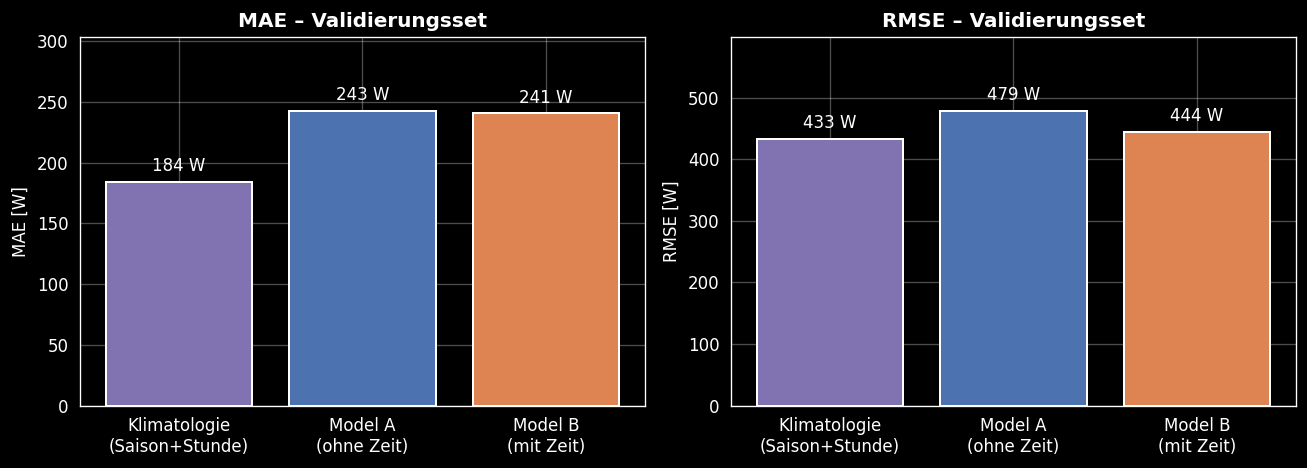

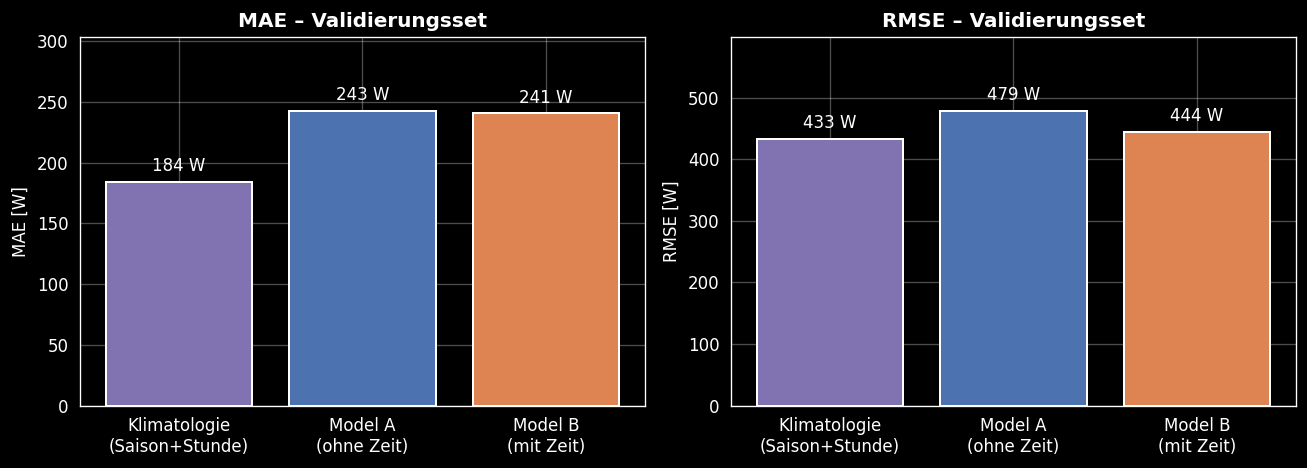

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

models = [
    "Klimatologie (val)",
    "Model A – ohne Zeit (val)", "Model B – mit Zeit (val)",
]
labels = ["Klimatologie\n(Saison+Stunde)", "Model A\n(ohne Zeit)", "Model B\n(mit Zeit)"]
colors = ["#8172B2", "#4C72B0", "#DD8452"]

for ax, metric, title in [
    (axes[0], "mae",  "MAE – Validierungsset"),
    (axes[1], "rmse", "RMSE – Validierungsset"),
]:
    vals = [results_df.loc[m, metric] for m in models]
    bars = ax.bar(labels, vals, color=colors, edgecolor="white", linewidth=1.2)
    ax.bar_label(bars, fmt="%.0f W", padding=4, fontsize=10)
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_ylabel(f"{metric.upper()} [W]")
    ax.set_ylim(0, max(vals) * 1.25)


plt.tight_layout()
plt.show()

## 6 · Beispielwoche

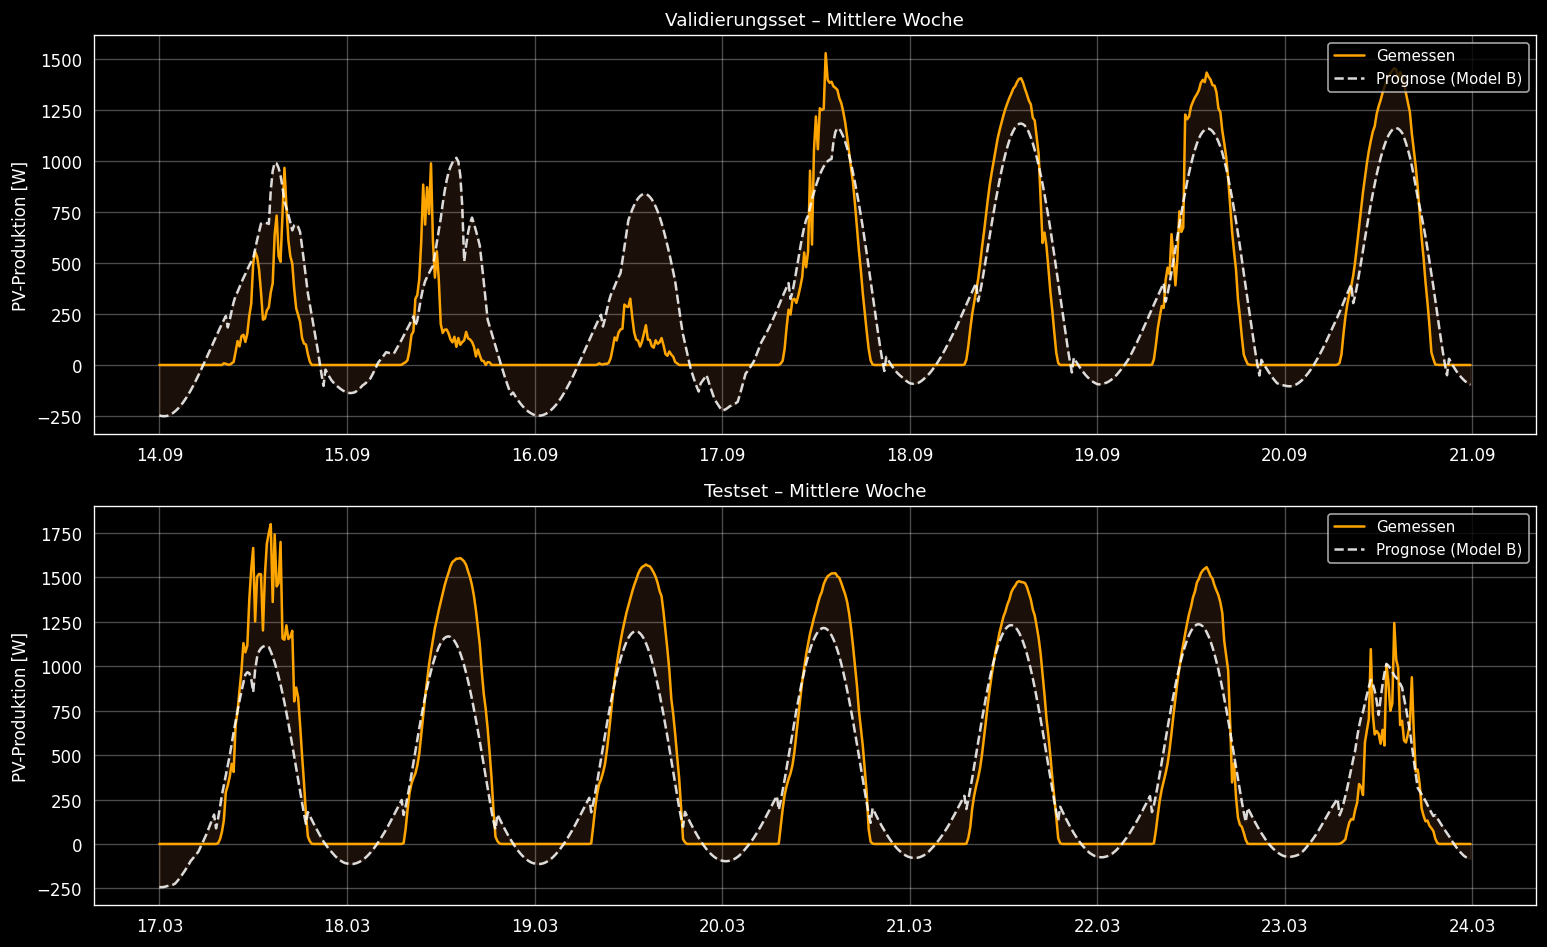

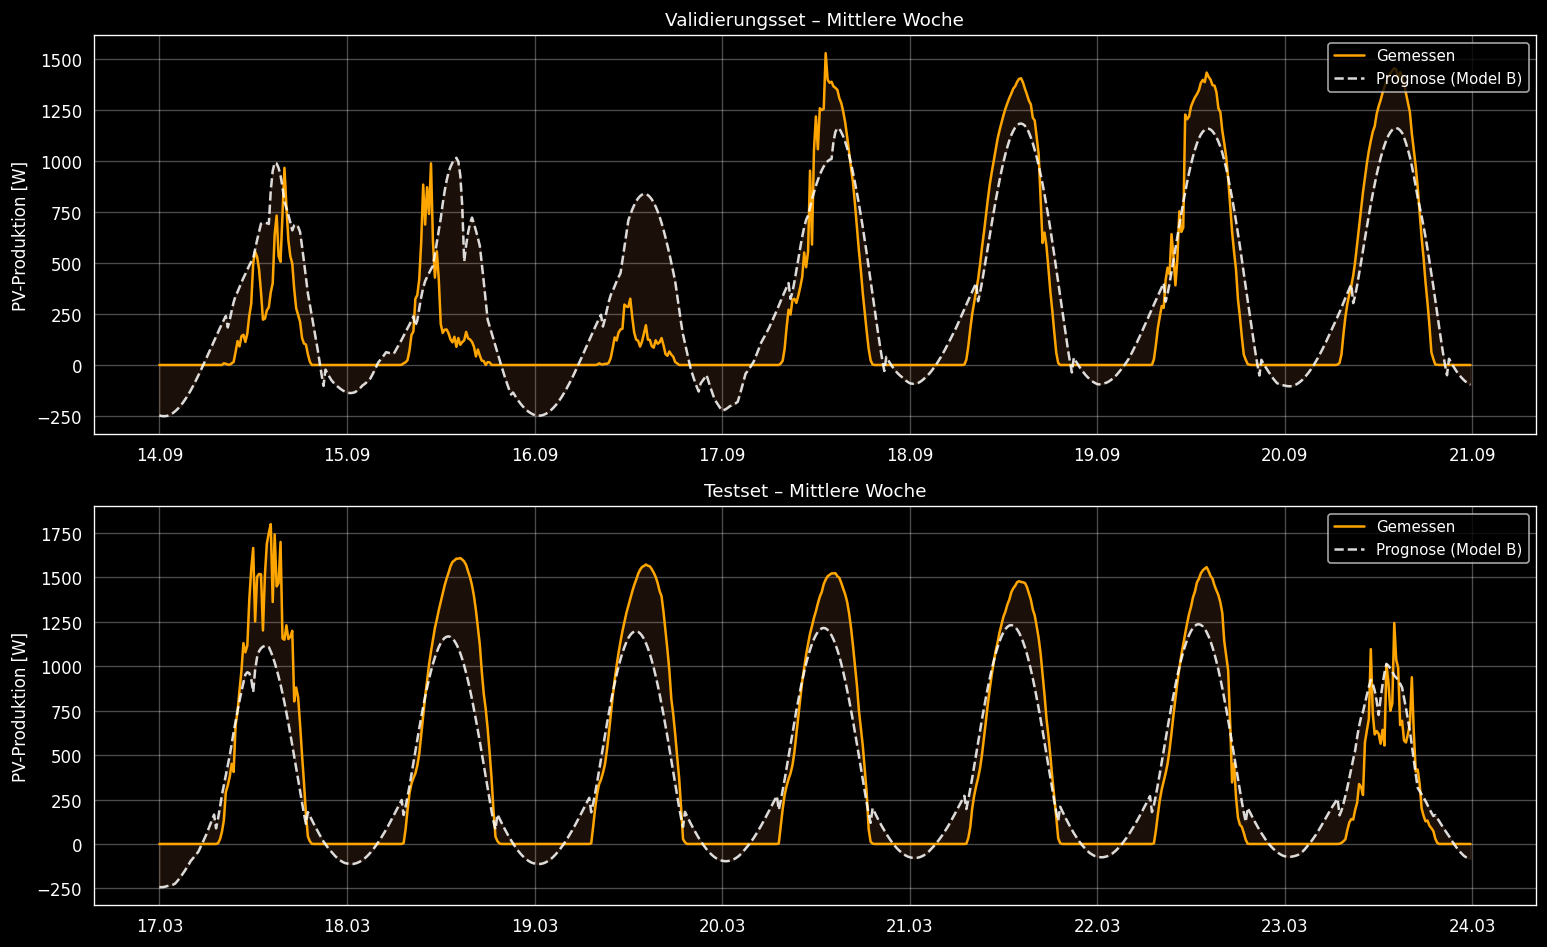

In [18]:
def plot_week(ax, df_split, y_pred, title):
    mid  = df_split["timestamp"].iloc[len(df_split) // 2].floor("D")
    mask = (df_split["timestamp"] >= mid) & (
           df_split["timestamp"] <  mid + pd.Timedelta(days=7))
    sub  = df_split[mask].set_index("timestamp")
    pred = y_pred.reindex(sub.index)

    ax.plot(sub.index, sub[TARGET], label="Gemessen",
            color="orange", linewidth=1.5)
    ax.plot(sub.index, pred, label="Prognose (Model B)",
            color="white", linewidth=1.5, linestyle="--", alpha=0.85)
    ax.fill_between(sub.index, sub[TARGET], pred, alpha=0.12, color="#DD8452")
    ax.set_title(title, fontsize=11)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%d.%m"))
    ax.xaxis.set_major_locator(mdates.DayLocator())
    ax.legend(loc="upper right", fontsize=9)
    ax.set_ylabel("PV-Produktion [W]")

fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=False)
plot_week(axes[0], val,  pred_b_val,  "Validierungsset – Mittlere Woche")
plot_week(axes[1], test, pred_b_test, "Testset – Mittlere Woche")
plt.tight_layout()
plt.show()

## 7 · Residualanalyse

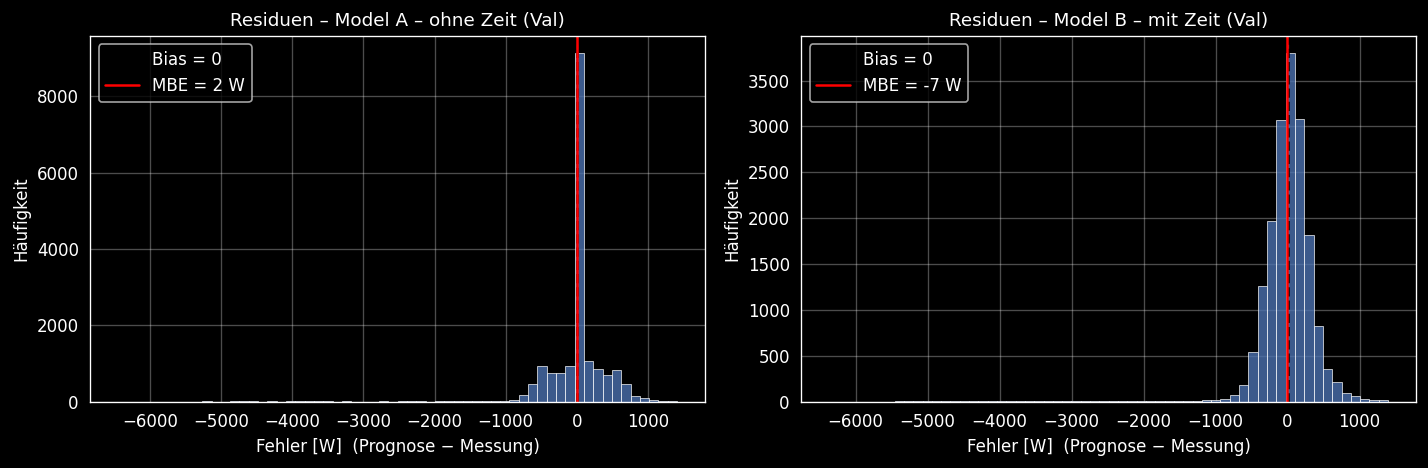

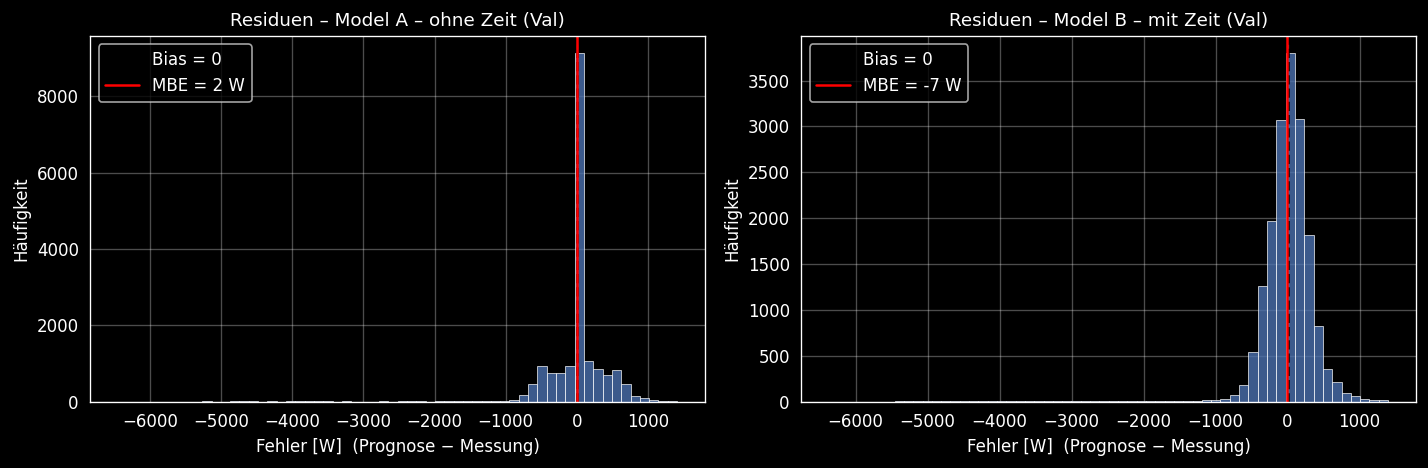

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, name, yt, yp in [
    (axes[0], "Model A – ohne Zeit (Val)", y_val, pred_a_val),
    (axes[1], "Model B – mit Zeit (Val)",  y_val, pred_b_val),
]:
    res = (yp - yt).dropna()
    ax.hist(res, bins=60, color="#4C72B0", edgecolor="white",
            linewidth=0.5, alpha=0.8)
    ax.axvline(0,           color="black", lw=1.5, ls="--", label="Bias = 0")
    ax.axvline(res.mean(),  color="red",   lw=1.5, ls="-",
               label=f"MBE = {res.mean():.0f} W")
    ax.set_title(f"Residuen – {name}", fontsize=11)
    ax.set_xlabel("Fehler [W]  (Prognose − Messung)")
    ax.set_ylabel("Häufigkeit")
    ax.legend()

plt.tight_layout()
plt.show()

## 9 · Ergebnisse speichern

In [21]:
def make_predict_fn(model):
    def predict_fn(df, features):
        X = df.set_index("timestamp")[features]
        return pd.Series(model.predict(X), index=X.index)
    return predict_fn

seasonal_means = fit_climatological_mean_by_season(train, TARGET)
ref_fn = lambda df, _: predict_climatological_mean_by_season(seasonal_means, df).set_axis(
    df.set_index("timestamp").index
)

for model_name, model, fset in [
    ("linear_regression_base",           model_a, "BASE"),
    ("linear_regression_base_with_time", model_b, "BASE_WITH_TIME"),
]:
    feats = FEATURE_SETS[fset].features
    result = run_pipeline(
        model_name=model_name,
        predict_fn=make_predict_fn(model),
        train=train,
        val=val,
        features=feats,
        feature_set_key=fset,
        results_dir=RESULTS_DIR,
        ref_predict_fn=ref_fn,
    )
    if RUN_TEST:
        evaluate_on_test(result, make_predict_fn(model), test, feats, RESULTS_DIR, ref_predict_fn=ref_fn)


Saved: ../../results/01_linear_regression/linear_regression_base.json
Saved: ../../results/01_linear_regression/linear_regression_base_with_time.json
Saved: ../../results/01_linear_regression/linear_regression_base.json
Saved: ../../results/01_linear_regression/linear_regression_base_with_time.json
